In [55]:
#Packpages
import h5py
import numpy as np
from hdf5read import *
import os
import pandas as pd
import datetime
from datetime import datetime, timedelta, timezone
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.dates as mdates

In [2]:
dirrs = ['/media/cportilla/HDD/Valley/HDF5/08_12_pair23',
         '/media/cportilla/HDD/Valley/HDF5/08_13_pair23',
         '/media/cportilla/HDD/Valley/HDF5/08_14_pair23',
         '/media/cportilla/HDD/Valley/HDF5/08_15_pair23']
full_paths = []
for dirr in dirrs:
    all_files=os.listdir(dirr)
    files = [ fname for fname in all_files if fname.endswith('.hdf5')]
    files=sorted(files); print(files)
    filenames = dirr + files[-1]

    full_paths.append([os.path.join(dirr, f) for f in files])
    

['jro20250812_171939.hdf5']
['jro20250813_050001.hdf5']
['jro20250814_050001.hdf5']
['jro20250815_050001.hdf5']


In [3]:
full_paths = [full_paths[i][0] for i in range(len(full_paths))] # [:][0]

In [ ]:
hdf5read.load_data_V2

In [4]:
def load_data_V2(filepath, data_keys):
    data_vars = {}
    with h5py.File(filepath, 'r') as f:
        data_group = f['Data']
        
        for key in data_keys:
            print("data_group", data_group)
            if key in data_group:
                print("True")
                item = data_group[key]
                if isinstance(item, h5py.Group):  # like data_dop/channel00
                    ds = list(item.keys())[0]
                    try:
                        data_vars[key] = item[ds][:]
                    except Exception:
                        data_vars[key] = np.full(item[ds].shape, np.nan)
                else:
                    try:
                        data_vars[key] = item[:]
                    except Exception:
                        data_vars[key] = np.full(item.shape, np.nan)
            else:
                data_vars[key] = np.nan
    
    return data_vars

In [45]:
import numpy as np
import h5py
import os
from datetime import datetime, timezone, timedelta
from concurrent.futures import ThreadPoolExecutor  # or ProcessPoolExecutor

data_keys = ['/Data/Array Layout/2D Parameters/ne','/Data/Array Layout/gdalt','/Data/Array Layout/timestamps']
data_acc = {key: [] for key in data_keys}

# Define wrapper to pass args to load_data
def load_one_file(filename):
    print(f"Loading {filename}")
    return load_data_V2(filename, data_keys)

# Optional: parallel loading (good for SSDs or small files)
use_parallel = False

if use_parallel:
    with ThreadPoolExecutor(max_workers=4) as executor:
        all_data = list(executor.map(load_one_file, full_paths))
else:
    all_data = [load_one_file(fn) for fn in full_paths]

# Accumulate each key across files
for data in all_data:
    for key in data_keys:
        data_acc[key].append(data[key])
# Get constant metadata once
heights = load_metadata(full_paths[0], metadata_keys=['heightList'])['heightList']

# Final arrays
ne = np.concatenate(data_acc[data_keys[0]], axis=1)
heights = data_acc[data_keys[1]][0]
timestamps = np.concatenate(data_acc[data_keys[2]], axis=0)


Loading /media/cportilla/HDD/Valley/HDF5/08_12_pair23/jro20250812_171939.hdf5
data_group <HDF5 group "/Data" (2 members)>
True
data_group <HDF5 group "/Data" (2 members)>
True
data_group <HDF5 group "/Data" (2 members)>
True
Loading /media/cportilla/HDD/Valley/HDF5/08_13_pair23/jro20250813_050001.hdf5
data_group <HDF5 group "/Data" (2 members)>
True
data_group <HDF5 group "/Data" (2 members)>
True
data_group <HDF5 group "/Data" (2 members)>
True
Loading /media/cportilla/HDD/Valley/HDF5/08_14_pair23/jro20250814_050001.hdf5
data_group <HDF5 group "/Data" (2 members)>
True
data_group <HDF5 group "/Data" (2 members)>
True
data_group <HDF5 group "/Data" (2 members)>
True
Loading /media/cportilla/HDD/Valley/HDF5/08_15_pair23/jro20250815_050001.hdf5
data_group <HDF5 group "/Data" (2 members)>
True
data_group <HDF5 group "/Data" (2 members)>
True
data_group <HDF5 group "/Data" (2 members)>
True


In [46]:
print("ne:" ,np.shape(ne))
print("ne:" ,np.shape(heights))
print("ne:" ,np.shape(timestamps))

ne: (109, 797)
ne: (109,)
ne: (797,)


In [66]:
heights[104]

384.00001525878906

In [47]:
LTime = [datetime.fromtimestamp(ts, timezone.utc) - timedelta(hours=5) for ts in timestamps]

/home/cportilla/anaconda3/envs/mad_test/lib/python3.6/site-packages/ipykernel_launcher.py:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  after removing the cwd from sys.path.


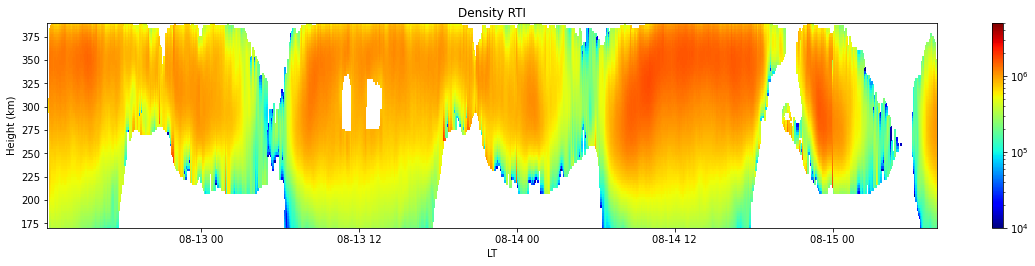

In [74]:
# snr
fig = plt.figure(figsize=(16,3.5))
ax = fig.add_subplot(111)
RTI = ax.pcolormesh(LTime,heights,ne,cmap='jet',norm=colors.LogNorm(vmin=1e4,vmax=5e6))
plt.colorbar(RTI)
#date_format = mdates.DateFormatter('%H:%M')
#ax.xaxis.set_major_formatter(date_format)

plt.ylim([170,390])
plt.xlabel('LT')
plt.ylabel('Height (km)')
plt.title('Density RTI')
plt.tight_layout(pad=0)
plt.show()